# JA4+ Decomposed Features (Random Forest)

## Data Loading and Initial Filtering

This section loads the parsed fingerprint dataset, keeps the columns required for the JA4+ experiment, removes incomplete rows, and prepares the target device label.

In [ ]:
import pandas as pd

# Select the parsed fingerprint feature columns and the target device label. 
selected_columns = [
    "device_name",
    "ja4",
    "ja4s",
    "ja4t",
    "ja4ts",
    "ja4x",
    
    # JA4
    "ja4_protocol",
    "ja4_tls_version",
    "ja4_sni_type",
    "ja4_n_ciphers",
    "ja4_n_extensions",
    "ja4_alpn",
    "ja4_cipher_hash",
    "ja4_extension_hash",
    
    # JA4S
    "ja4s_protocol",
    "ja4s_tls_version",
    "ja4s_n_extensions",
    "ja4s_alpn",
    "ja4s_cipher_chosen",
    "ja4s_extension_hash",
    
    # JA4T
    "ja4t_window_size",
    "ja4t_option_list",
    "ja4t_mss",
    "ja4t_scale",
    "ja4t_num_options",
    "ja4t_has_timestamp",
    "ja4t_has_sack",
    "ja4t_has_window_scale",

    # JA4TS
    "ja4ts_window_size",
    "ja4ts_option_list",
    "ja4ts_mss",
    "ja4ts_scale",
    "ja4ts_num_options",
    "ja4ts_has_timestamp",
    "ja4ts_has_sack",
    "ja4ts_has_window_scale",
    
    # JA4X
    "ja4x_issuer_hash",
    "ja4x_subject_hash",
    "ja4x_extensions_hash"

    
]

# Input CSV path
csv_path = "D:/TFG_GemmaBeatrizVate/1_Data/raw_fingerprints/raw_features.csv"

df = pd.read_csv(csv_path, dtype=str, low_memory=False)
df = df[
    df["ja4"].notna()
    & df["ja4"].str.strip().ne("")
    & df["ja4"].str.strip().str.lower().ne("(empty)")
    & df["ja4"].str.strip().str.lower().ne("(emtpy)")
    
    & df["ja4s"].notna()
    & df["ja4s"].str.strip().ne("")
    & df["ja4s"].str.strip().str.lower().ne("(empty)")
    & df["ja4s"].str.strip().str.lower().ne("(emtpy)")
    
    & df["ja4t"].notna()
    & df["ja4t"].str.strip().ne("")
    & df["ja4t"].str.strip().str.lower().ne("(empty)")
    & df["ja4t"].str.strip().str.lower().ne("(emtpy)")
    
    & df["ja4ts"].notna()
    & df["ja4ts"].str.strip().ne("")
    & df["ja4ts"].str.strip().str.lower().ne("(empty)")
    & df["ja4ts"].str.strip().str.lower().ne("(emtpy)")
    
    
    & df["ja4x"].notna()
    & df["ja4x"].str.strip().ne("")
    & df["ja4x"].str.strip().str.lower().ne("(empty)")
    & df["ja4x"].str.strip().str.lower().ne("(emtpy)")
    
]

# Keep only the columns required for this experiment
df = df[selected_columns]

print(df.head())
print(f"Number of rows (samples) in the dataset: {len(df)}")

                         device_name                                   ja4  \
394                    Rbcior_Camera  t12d040600_39def8a70f78_9b994c9d23f8   
6039             Harman_Kardon_Audio  t12i0507h2_2af0c3a5c862_e0fb7d0a714d   
6110                 SmartThings_Hub  t13d311000_e8f1e7e78f70_5ac7197df9d2   
6466   Amazon_Alexa_Echo_Dot_2_Audio  t12i0407h2_dd22d19553a2_453ce47662e7   
19710                  Rbcior_Camera  t12d040600_39def8a70f78_9b994c9d23f8   

                            ja4s                    ja4t  \
394    t120300_c027_7815a3cc5eb2  14600_2-4-8-1-3_1460_3   
6039   t120300_c02f_5935512bb26a  14600_2-4-8-1-3_1460_4   
6110   t120300_c02f_7a0270e617ef  29200_2-4-8-1-3_1460_5   
6466   t120300_c02f_460f64128655  29200_2-4-8-1-3_1460_5   
19710  t120300_c027_7815a3cc5eb2  14600_2-4-8-1-3_1460_3   

                         ja4ts                            ja4x ja4_protocol  \
394     65535_2-4-8-1-3_1460_9  f1bb6372_f1bb6372_000000000000            t   
6039    2896

This section summarizes the number of fingerprint samples and distinct fingerprint combinations observed for each device.

Total number of fingerprints
device_name
HeimVision_Smart_WiFi_Camera      38
Rbcior_Camera                     14
Yi_Indoor_Camera                  10
Harman_Kardon_Audio                9
Yi_Outdoor_Camera                  9
Amazon_Echo_Show_Audio             7
Amazon_Alexa_Echo_Dot_2_Audio      6
SmartThings_Hub                    3
UNKNOWN                            3
Amazon_Alexa_Echo_Studio_Audio     1
Amazon_Alexa_Echo_Dot_1_Audio      1
AeoTec_Smart_Home_Hub              1
Arlo_Q_Indoor_Camera               1

Number of distinct fingerprints
device_name
UNKNOWN                           3
Amazon_Alexa_Echo_Dot_1_Audio     1
Amazon_Alexa_Echo_Dot_2_Audio     1
Amazon_Alexa_Echo_Studio_Audio    1
AeoTec_Smart_Home_Hub             1
Amazon_Echo_Show_Audio            1
Arlo_Q_Indoor_Camera              1
HeimVision_Smart_WiFi_Camera      1
Harman_Kardon_Audio               1
Rbcior_Camera                     1
SmartThings_Hub                   1
Yi_Indoor_Camera                  1
Y

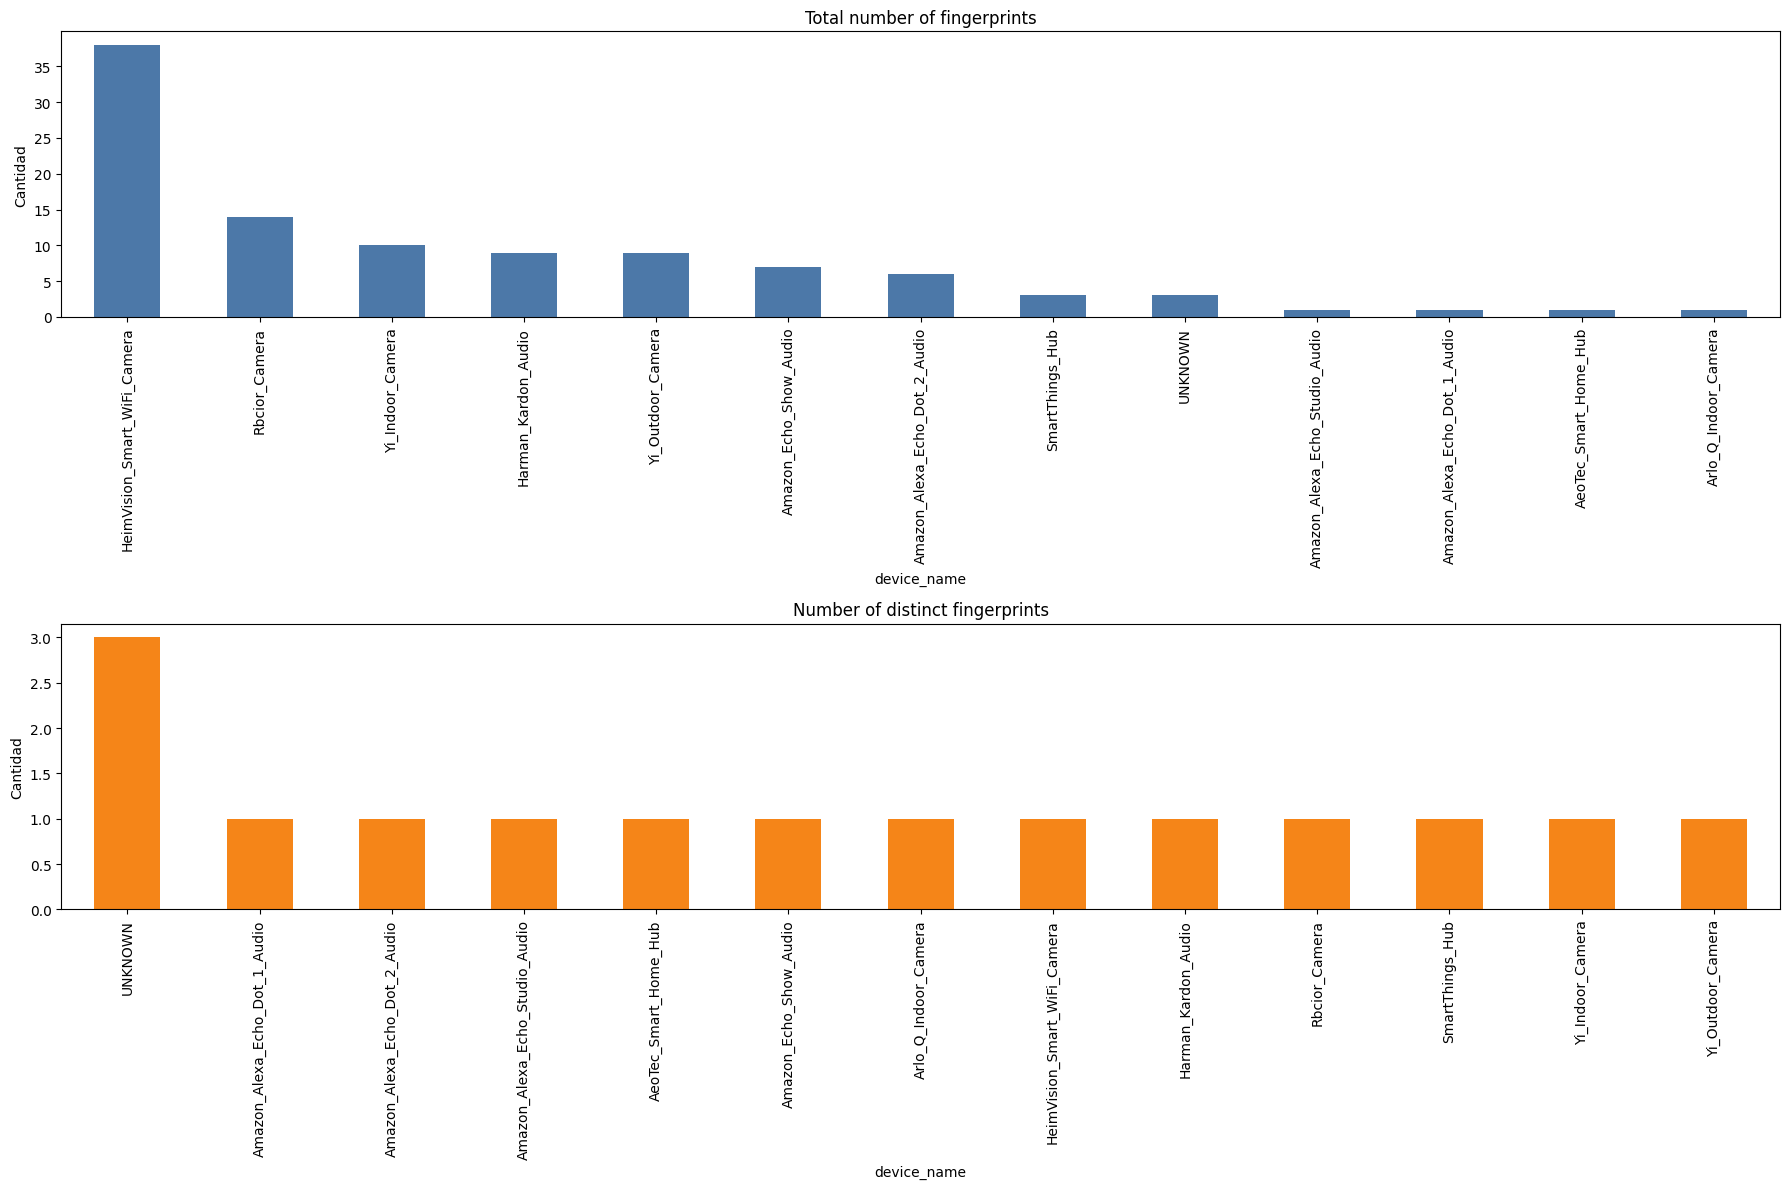

In [2]:
import matplotlib.pyplot as plt

total_fingerprints = df.groupby("device_name")["ja4"].count().sort_values(ascending=False)
distinct_fingerprints = df.groupby("device_name")["ja4"].nunique().sort_values(ascending=False)

print("Total number of fingerprints")
print(total_fingerprints.to_string())
print()
print("Number of distinct fingerprints")
print(distinct_fingerprints.to_string())

fig, axes = plt.subplots(2, 1, figsize=(18, 12))

total_fingerprints.plot(kind="bar", ax=axes[0], color="#4C78A8")
axes[0].set_title("Total number of fingerprints")
axes[0].set_xlabel("device_name")
axes[0].set_ylabel("Cantidad")
axes[0].tick_params(axis="x", rotation=90)

distinct_fingerprints.plot(kind="bar", ax=axes[1], color="#F58518")
axes[1].set_title("Number of distinct fingerprints")
axes[1].set_xlabel("device_name")
axes[1].set_ylabel("Cantidad")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

In [3]:
# Sample thresholds per device.
min_samples_per_device = 3
max_samples_per_device = 60

device_counts = df["device_name"].value_counts()
valid_devices = device_counts[device_counts >= min_samples_per_device].index

df = df[df["device_name"].isin(valid_devices)]

if max_samples_per_device is not None:
    df = (
        df.groupby("device_name", group_keys=False)
        .head(max_samples_per_device)
        .reset_index(drop=True)
    )
else:
    df = df.reset_index(drop=True)

filtered_counts = df["device_name"].value_counts().sort_values(ascending=False)

print("Number of records per device_name after filtering")
print(filtered_counts.to_string())
print()
print(f"Umbral minimo aplicado: {min_samples_per_device}")
print(f"Umbral maximum aplicado: {max_samples_per_device}")
print(f"Number of devices kept: {len(valid_devices)}")
print(f"Total number of records after filtering: {len(df)}")
print()
print(df.head())

Number of records per device_name after filtering
device_name
HeimVision_Smart_WiFi_Camera     38
Rbcior_Camera                    14
Yi_Indoor_Camera                 10
Harman_Kardon_Audio               9
Yi_Outdoor_Camera                 9
Amazon_Echo_Show_Audio            7
Amazon_Alexa_Echo_Dot_2_Audio     6
UNKNOWN                           3
SmartThings_Hub                   3

Umbral minimo aplicado: 3
Umbral maximo aplicado: 60
Number of devices kept: 9
Total number of records after filtering: 99

                     device_name                                   ja4  \
0                  Rbcior_Camera  t12d040600_39def8a70f78_9b994c9d23f8   
1            Harman_Kardon_Audio  t12i0507h2_2af0c3a5c862_e0fb7d0a714d   
2                SmartThings_Hub  t13d311000_e8f1e7e78f70_5ac7197df9d2   
3  Amazon_Alexa_Echo_Dot_2_Audio  t12i0407h2_dd22d19553a2_453ce47662e7   
4                  Rbcior_Camera  t12d040600_39def8a70f78_9b994c9d23f8   

                        ja4s                

## Feature Encoding

This section converts the selected parsed fingerprint fields into numerical features that can be used by the multiclass Random Forest model.

The following steps convert the selected JA4-family variables into a tabular representation suitable for multiclass RandomForest classification.

In [4]:
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, f1_score

# ============ PER-DEVICE SPLIT CONFIGURATION ============
# Ensure every device appears in train (70%), validation (10%), and test (20%)

feature_columns = [
    "ja4_tls_version",
    "ja4_sni_type",
    "ja4_n_ciphers",
    "ja4_n_extensions",
    "ja4_alpn",
    "ja4_cipher_hash",
    "ja4_extension_hash",
    
    "ja4s_protocol",
    "ja4s_tls_version",
    "ja4s_n_extensions",
    "ja4s_alpn",
    "ja4s_cipher_chosen",
    "ja4s_extension_hash",
    
    "ja4t_window_size",
    "ja4t_option_list",
    "ja4t_mss",
    "ja4t_scale",
    "ja4t_num_options",
    "ja4t_has_timestamp",
    "ja4t_has_sack",
    "ja4t_has_window_scale",

    "ja4ts_window_size",
    "ja4ts_option_list",
    "ja4ts_mss",
    "ja4ts_scale",
    "ja4ts_num_options",
    "ja4ts_has_timestamp",
    "ja4ts_has_sack",
    "ja4ts_has_window_scale",
    
    "ja4x_issuer_hash",
    "ja4x_subject_hash",
    "ja4x_extensions_hash"
]
target_column = "device_name"

categorical_features = [
    "ja4_tls_version",
    "ja4_sni_type",
    "ja4_alpn",
    "ja4_cipher_hash",
    "ja4_extension_hash",
    
    "ja4s_protocol",
    "ja4s_tls_version",
    "ja4s_alpn",
    "ja4s_cipher_chosen",
    "ja4s_extension_hash",
    
    "ja4t_option_list",
    
    "ja4ts_option_list",
    
    "ja4x_issuer_hash",
    "ja4x_subject_hash",
    "ja4x_extensions_hash"
]
numeric_features = [
    "ja4_n_ciphers",
    "ja4_n_extensions",
    "ja4s_n_extensions",
    
    "ja4t_window_size",
    "ja4t_mss",
    "ja4t_scale",
    "ja4t_num_options",
    "ja4t_has_timestamp",
    "ja4t_has_sack",
    "ja4t_has_window_scale",
    
    "ja4ts_window_size",
    "ja4ts_mss",
    "ja4ts_scale",
    "ja4ts_num_options",
    "ja4ts_has_timestamp",
    "ja4ts_has_sack",
    "ja4ts_has_window_scale",
]

df_model = df[feature_columns + [target_column]].copy()

for column in categorical_features + [target_column]:
    df_model[column] = (
        df_model[column]
        .fillna("unknown")
        .astype(str)
        .str.strip()
        .str.lower()
    )

for column in numeric_features:
    df_model[column] = pd.to_numeric(df_model[column], errors="coerce")

df_model = df_model.dropna(subset=numeric_features).reset_index(drop=True)

class_counts_after_cleaning = df_model[target_column].value_counts()
valid_classes_for_split = class_counts_after_cleaning[class_counts_after_cleaning >= 3].index
removed_classes = sorted(set(class_counts_after_cleaning.index) - set(valid_classes_for_split))

if removed_classes:
    print(
        "Classes excluded after adding JA4TS because they do not have at least 3 valid samples ",
        "after numeric cleaning:",
        removed_classes,
    )
    df_model = df_model[df_model[target_column].isin(valid_classes_for_split)].reset_index(drop=True)

# ============ CUSTOM PER-DEVICE SPLIT ============
# For each device: 70% train, 10% validation, 20% test
# This guarantees that every device is present in all three splits

X = df_model[feature_columns].copy()
y = df_model[target_column].copy()

X_train_list = []
X_val_list = []
X_test_list = []
y_train_list = []
y_val_list = []
y_test_list = []

unique_devices = df_model[target_column].unique()

for device in unique_devices:
    device_mask = df_model[target_column] == device
    X_device = X[device_mask].reset_index(drop=True)
    y_device = y[device_mask].reset_index(drop=True)
    
    n_samples = len(X_device)
    
    # Split: 70% train, 10% val, 20% test
    X_temp, X_test_device, y_temp, y_test_device = train_test_split(
        X_device, y_device, test_size=0.2, random_state=42, shuffle=True
    )
    
    # Del 80% restante: 70/(70+10) = 87.5% para train, 12.5% para val
    train_ratio = 0.70 / 0.80  # 0.875
    X_train_device, X_val_device, y_train_device, y_val_device = train_test_split(
        X_temp, y_temp, train_size=train_ratio, random_state=42, shuffle=True
    )
    
    X_train_list.append(X_train_device)
    X_val_list.append(X_val_device)
    X_test_list.append(X_test_device)
    y_train_list.append(y_train_device)
    y_val_list.append(y_val_device)
    y_test_list.append(y_test_device)

# Concatenate all per-device splits
X_train_raw = pd.concat(X_train_list, ignore_index=True)
X_val_raw = pd.concat(X_val_list, ignore_index=True)
X_test_raw = pd.concat(X_test_list, ignore_index=True)
y_train_raw = pd.concat(y_train_list, ignore_index=True)
y_val_raw = pd.concat(y_val_list, ignore_index=True)
y_test_raw = pd.concat(y_test_list, ignore_index=True)

print("Split por device (70% train, 10% val, 20% test):")
print(f"Train size: {len(X_train_raw)}")
print(f"Validation size: {len(X_val_raw)}")
print(f"Test size: {len(X_test_raw)}")
print()
print("devices en train:", sorted(y_train_raw.unique()))
print("devices en val:", sorted(y_val_raw.unique()))
print("devices en test:", sorted(y_test_raw.unique()))
print()

# ============ ONE-HOT ENCODING ============
X_train = pd.get_dummies(
    X_train_raw,
    columns=categorical_features,
    dtype=np.int8,
    dummy_na=False,
    drop_first=False,
    prefix_sep="=",
)
X_val = pd.get_dummies(
    X_val_raw,
    columns=categorical_features,
    dtype=np.int8,
    dummy_na=False,
    drop_first=False,
    prefix_sep="=",
)
X_test = pd.get_dummies(
    X_test_raw,
    columns=categorical_features,
    dtype=np.int8,
    dummy_na=False,
    drop_first=False,
    prefix_sep="=",
)

# Align one-hot encoded columns across train, validation, and test
union_columns = set(X_train.columns) | set(X_val.columns) | set(X_test.columns)
for col in union_columns:
    if col not in X_train.columns:
        X_train[col] = 0
    if col not in X_val.columns:
        X_val[col] = 0
    if col not in X_test.columns:
        X_test[col] = 0

X_train = X_train[sorted(union_columns)]
X_val = X_val[sorted(union_columns)]
X_test = X_test[sorted(union_columns)]

# ============ LABEL ENCODING ============
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_raw)
y_val = label_encoder.transform(y_val_raw)
y_test = label_encoder.transform(y_test_raw)
class_names = label_encoder.classes_

print(f"Valid records after cleaning: {len(df_model)}")
print(f"Target classes: {len(class_names)}")
print(f"Train size: {len(X_train)}")
print(f"Validation size: {len(X_val)}")
print(f"Test size: {len(X_test)}")
print(f"Number of columns after one-hot encoding: {X_train.shape[1]}")
print("First classes:", class_names[:10])

Split por device (70% train, 10% val, 20% test):
Train size: 62
Validation size: 14
Test size: 23

Devices en train: ['amazon_alexa_echo_dot_2_audio', 'amazon_echo_show_audio', 'harman_kardon_audio', 'heimvision_smart_wifi_camera', 'rbcior_camera', 'smartthings_hub', 'unknown', 'yi_indoor_camera', 'yi_outdoor_camera']
Devices en val: ['amazon_alexa_echo_dot_2_audio', 'amazon_echo_show_audio', 'harman_kardon_audio', 'heimvision_smart_wifi_camera', 'rbcior_camera', 'smartthings_hub', 'unknown', 'yi_indoor_camera', 'yi_outdoor_camera']
Devices en test: ['amazon_alexa_echo_dot_2_audio', 'amazon_echo_show_audio', 'harman_kardon_audio', 'heimvision_smart_wifi_camera', 'rbcior_camera', 'smartthings_hub', 'unknown', 'yi_indoor_camera', 'yi_outdoor_camera']

Valid records after cleaning: 99
Target classes: 9
Train size: 62
Validation size: 14
Test size: 23
Number of columns after one-hot encoding: 92
First classes: ['amazon_alexa_echo_dot_2_audio' 'amazon_echo_show_audio'
 'harman_kardon_audio'

In [5]:
print("\nClass distribution in y_train_raw:")
print(y_train_raw.value_counts(normalize=True).sort_index())

print("\nClass distribution in y_val_raw:")
print(y_val_raw.value_counts(normalize=True).sort_index())

print("\nClass distribution in y_test_raw:")
print(y_test_raw.value_counts(normalize=True).sort_index())


Class distribution in y_train_raw:
device_name
amazon_alexa_echo_dot_2_audio    0.048387
amazon_echo_show_audio           0.064516
harman_kardon_audio              0.096774
heimvision_smart_wifi_camera     0.419355
rbcior_camera                    0.145161
smartthings_hub                  0.016129
unknown                          0.016129
yi_indoor_camera                 0.096774
yi_outdoor_camera                0.096774
Name: proportion, dtype: float64

Class distribution in y_val_raw:
device_name
amazon_alexa_echo_dot_2_audio    0.071429
amazon_echo_show_audio           0.071429
harman_kardon_audio              0.071429
heimvision_smart_wifi_camera     0.285714
rbcior_camera                    0.142857
smartthings_hub                  0.071429
unknown                          0.071429
yi_indoor_camera                 0.142857
yi_outdoor_camera                0.071429
Name: proportion, dtype: float64

Class distribution in y_test_raw:
device_name
amazon_alexa_echo_dot_2_audio    0.08

In [6]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score
import warnings
warnings.filterwarnings('ignore')

# ============ GRIDSEARCHCV ============
# Hyperparameter search using macro F1 as the main metric
# NOTE: This notebook currently tests only one configuration.
# FUTURE: Uncomment this block to test multiple min/max sample settings. 

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [20, 30, None],
    'min_samples_split': [2, 10],
    'min_samples_leaf': [1, 4],
    'max_features': ['sqrt'],
    'class_weight': ['balanced'],
}

# Scorer: macro F1 (chosen to handle class imbalance)
macro_f1_scorer = make_scorer(f1_score, average='macro', zero_division=0)

# GridSearchCV with cross-validation on the training split
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    scoring=macro_f1_scorer,
    cv=5,  # 5-fold cross-validation
    n_jobs=-1,
    verbose=0,
)

print("Iniciando GridSearchCV...")
total_combinations = (
    len(param_grid['n_estimators']) * len(param_grid['max_depth']) * 
    len(param_grid['min_samples_split']) * len(param_grid['min_samples_leaf']) * 
    len(param_grid['max_features']) * len(param_grid['class_weight'])
)
print(f"parameters a probar: {total_combinations} combinations")
print(f"  - n_estimators: {param_grid['n_estimators']}")
print(f"  - max_depth: {param_grid['max_depth']}")
print(f"  - min_samples_split: {param_grid['min_samples_split']}")
print(f"  - min_samples_leaf: {param_grid['min_samples_leaf']}")
print(f"  - max_features: {param_grid['max_features']}")
print(f"  - class_weight: {param_grid['class_weight']}")
print()

grid_search.fit(X_train, y_train)

print("\n" + "="*80)
print("Best hyperparameters found:")
print(grid_search.best_params_)
print(f"Best cross-validated macro F1 score: {grid_search.best_score_:.4f}")
print("="*80)

# Use the best model found by GridSearchCV
rf_model = grid_search.best_estimator_

Iniciando GridSearchCV...
Parameters a probar: 24 combinations
  - n_estimators: [100, 200]
  - max_depth: [20, 30, None]
  - min_samples_split: [2, 10]
  - min_samples_leaf: [1, 4]
  - max_features: ['sqrt']
  - class_weight: ['balanced']


Best hyperparameters found:
{'class_weight': 'balanced', 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best cross-validated macro F1 score: 0.7360


In [7]:
print("Optimized RandomForest configuration:")
print(rf_model)
print()
print(f"Number of input features after one-hot encoding: {X_train.shape[1]}")
print(f"Number of target classes: {len(class_names)}")

Optimized RandomForest configuration:
RandomForestClassifier(class_weight='balanced', max_depth=20, n_jobs=-1,
                       random_state=42)

Number of input features after one-hot encoding: 92
Number of target classes: 9


## Model Training

This section trains or reuses the Random Forest configuration selected for the experiment and evaluates it on the train, validation, and test splits.

In [8]:
# The model has already been trained by GridSearchCV
# Evaluate performance on train, validation, and test

from sklearn.metrics import f1_score

train_predictions = rf_model.predict(X_train)
train_f1_macro = f1_score(y_train, train_predictions, average='macro', zero_division=0)

val_predictions = rf_model.predict(X_val)
val_f1_macro = f1_score(y_val, val_predictions, average='macro', zero_division=0)

print("Macro F1 score metrics:")
print(f"- Train macro F1: {train_f1_macro:.4f}")
print(f"- Val macro F1: {val_f1_macro:.4f}")

Metricas macro F1 score:
- Train macro F1: 0.8519
- Val macro F1: 0.8667


## Feature Importance

This section ranks the encoded model inputs by their contribution to the Random Forest decisions.

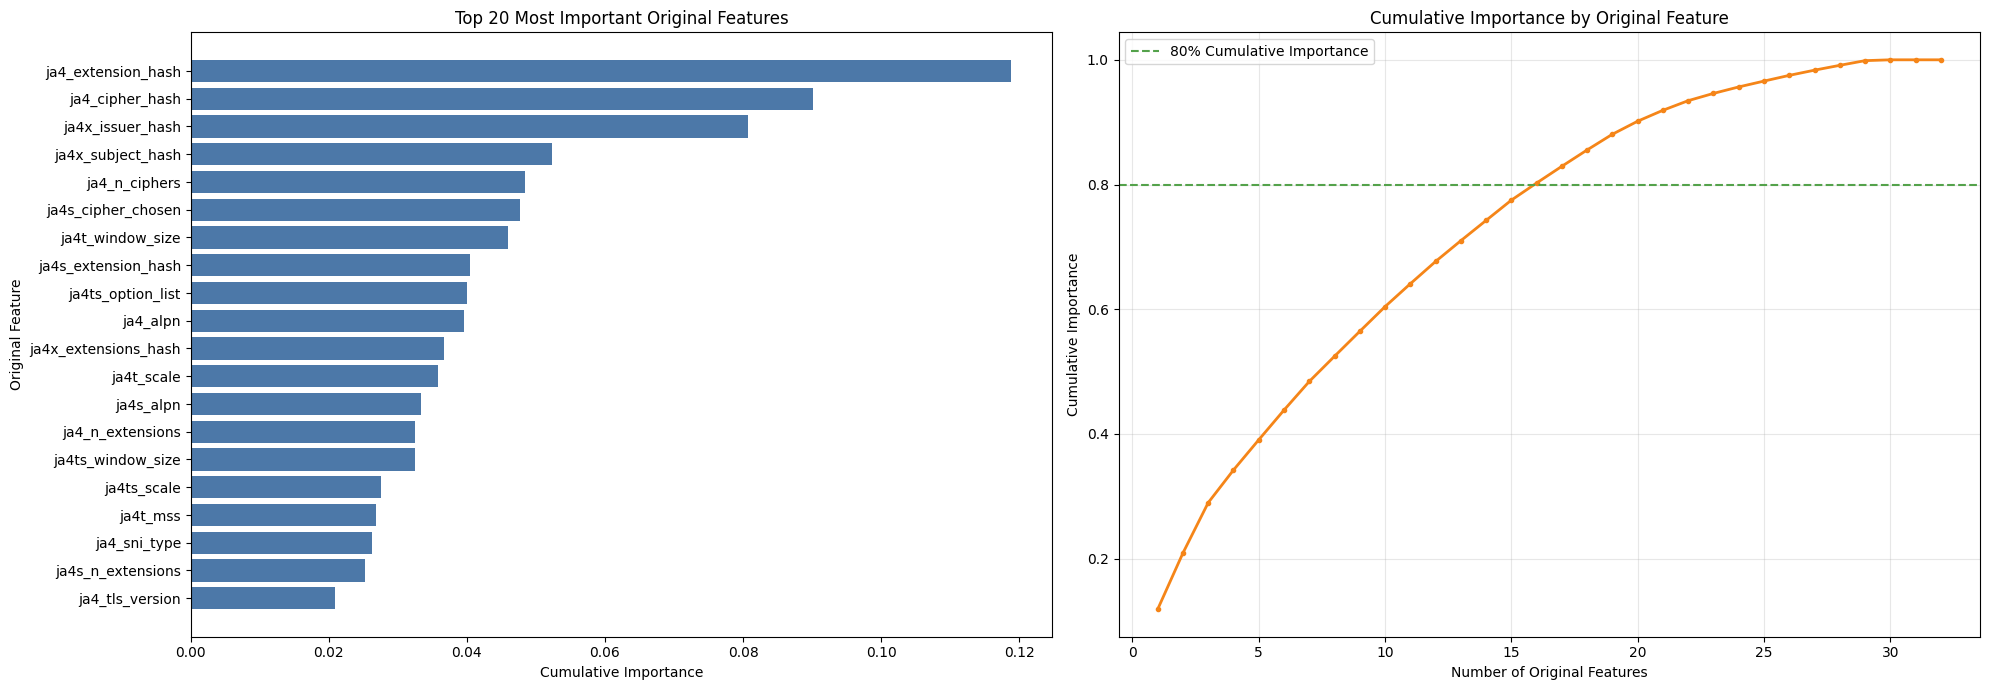

Top original features by cumulative importance:
     grouped_feature  importance
  ja4_extension_hash    0.118853
     ja4_cipher_hash    0.090197
    ja4x_issuer_hash    0.080703
   ja4x_subject_hash    0.052370
       ja4_n_ciphers    0.048432
  ja4s_cipher_chosen    0.047673
    ja4t_window_size    0.045935
 ja4s_extension_hash    0.040399
   ja4ts_option_list    0.039989
            ja4_alpn    0.039593
ja4x_extensions_hash    0.036678
          ja4t_scale    0.035742
           ja4s_alpn    0.033343
    ja4_n_extensions    0.032541
   ja4ts_window_size    0.032491
         ja4ts_scale    0.027509
            ja4t_mss    0.026821
        ja4_sni_type    0.026200
   ja4s_n_extensions    0.025174
     ja4_tls_version    0.020897


In [9]:
import matplotlib.pyplot as plt

feature_importance_df = pd.DataFrame(
    {
        "feature": X_train.columns,
        "importance": rf_model.feature_importances_,
    }
).sort_values("importance", ascending=False)

grouped_feature_importance_df = (
    feature_importance_df.assign(
        grouped_feature=feature_importance_df["feature"].str.split("=", n=1).str[0]
    )
    .groupby("grouped_feature", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

top_n = min(20, len(grouped_feature_importance_df))
top_features = grouped_feature_importance_df.head(top_n).sort_values("importance")
cumulative_importance = grouped_feature_importance_df["importance"].cumsum().to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

axes[0].barh(top_features["grouped_feature"], top_features["importance"], color="#4C78A8")
axes[0].set_title(f"Top {top_n} Most Important Original Features")
axes[0].set_xlabel("Cumulative Importance")
axes[0].set_ylabel("Original Feature")

axes[1].plot(
    range(1, len(cumulative_importance) + 1),
    cumulative_importance,
    color="#F58518",
    linewidth=2,
    marker="o",
    markersize=3,
    markevery=max(1, len(cumulative_importance) // 25),
)
axes[1].axhline(0.8, color="#54A24B", linestyle="--", label="80% Cumulative Importance")
axes[1].set_title("Cumulative Importance by Original Feature")
axes[1].set_xlabel("Number of Original Features")
axes[1].set_ylabel("Cumulative Importance")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Top original features by cumulative importance:")
print(grouped_feature_importance_df.head(20).to_string(index=False))

## Save the Trained Model

In [ ]:
import joblib
import json
from pathlib import Path

project_root = Path(r"D:\TFG_GemmaBeatrizVate")
if not project_root.exists():
    project_root = Path("/mnt/d/TFG_GemmaBeatrizVate")

model_dir = project_root / "3_Results" / "models" / "rf_ja4_plus_decomposed_gridsearch"
model_dir.mkdir(parents=True, exist_ok=True)

model_path = model_dir / "model.joblib"
joblib.dump(rf_model, model_path)

artifacts = {
    "experiment": "rf_ja4_plus_decomposed_gridsearch",
    "feature_columns": feature_columns,
    "categorical_features": categorical_features,
    "numeric_features": numeric_features,
    "class_names": class_names.tolist(),
    "best_params": grid_search.best_params_,
    "best_cv_macro_f1": float(grid_search.best_score_),
    "train_size": int(len(X_train)),
    "validation_size": int(len(X_val)),
    "test_size": int(len(X_test)),
    "min_samples_per_device": int(min_s),
    "max_samples_per_device": None if max_s is None else int(max_s),
}

artifacts_path = model_dir / "artifacts.json"
with artifacts_path.open("w", encoding="utf-8") as file:
    json.dump(artifacts, file, indent=2)

print(f"Model saved to: {model_path}")
print(f"Artifacts saved to: {artifacts_path}")

## Test Evaluation and Results

## Test Evaluation and Results

This section evaluates the final model on the test split, including the confusion matrix and the precision, recall, and F1-score values reported by sklearn.metrics.classification_report().

GENERAL RESULTS

Accuracy:
  - Train: 0.9032
  - Val:   0.9286
  - Test:  0.8696

Macro F1 Score (important for imbalanced classes):
  - Train: 0.8519
  - Val:   0.8667
  - Test:  0.7185

Top-k accuracy on the test split:
  - top_3_accuracy: 0.9565
  - top_5_accuracy: 0.9565

Average prediction time: 0.089434 s (89.434 ms)

CLASSIFICATION REPORT - TEST
                               precision    recall  f1-score   support

amazon_alexa_echo_dot_2_audio       1.00      1.00      1.00         2
       amazon_echo_show_audio       0.67      1.00      0.80         2
          harman_kardon_audio       1.00      1.00      1.00         2
 heimvision_smart_wifi_camera       1.00      1.00      1.00         8
                rbcior_camera       1.00      1.00      1.00         3
              smartthings_hub       1.00      1.00      1.00         1
                      unknown       0.00      0.00      0.00         1
             yi_indoor_camera       0.50      1.00      0.67         2
     

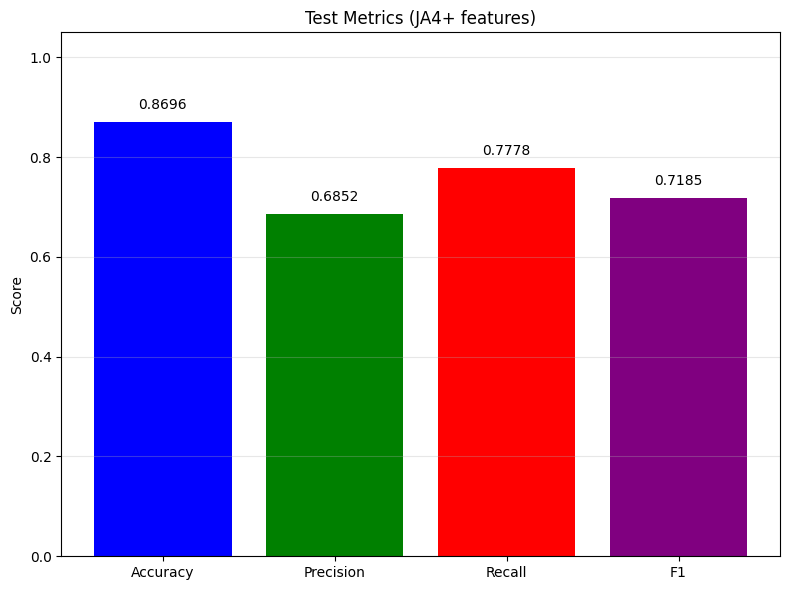

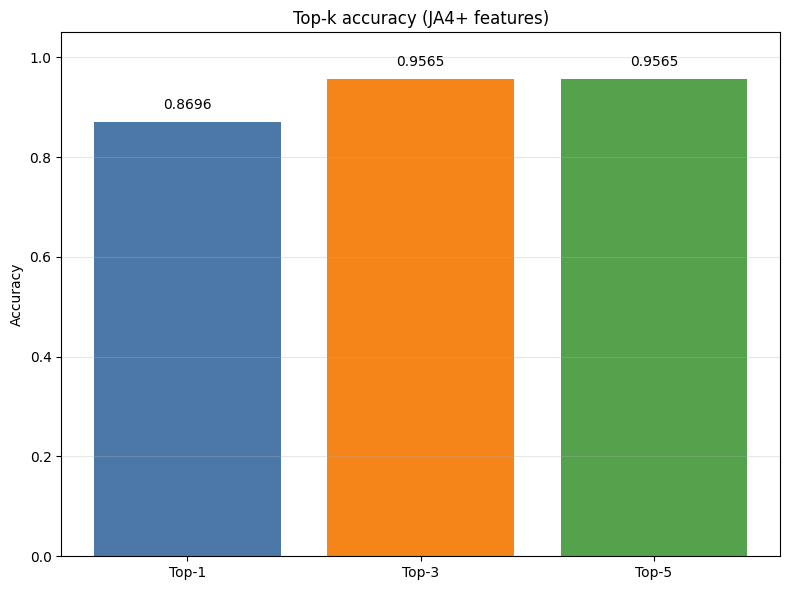

In [11]:
import time
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, top_k_accuracy_score, f1_score

# ============ TRAIN / VALIDATION / TEST EVALUATION ============

# Predictions for each split
train_predictions = rf_model.predict(X_train)
train_probabilities = rf_model.predict_proba(X_train)

val_predictions = rf_model.predict(X_val)
val_probabilities = rf_model.predict_proba(X_val)

test_predictions = rf_model.predict(X_test)
test_probabilities = rf_model.predict_proba(X_test)

# Accuracy metrics
train_accuracy = accuracy_score(y_train, train_predictions)
val_accuracy = accuracy_score(y_val, val_predictions)
test_accuracy = accuracy_score(y_test, test_predictions)

# Macro F1 metrics (important for imbalanced classes)
train_f1_macro = f1_score(y_train, train_predictions, average='macro', zero_division=0)
val_f1_macro = f1_score(y_val, val_predictions, average='macro', zero_division=0)
test_f1_macro = f1_score(y_test, test_predictions, average='macro', zero_division=0)

# Top-k accuracy
top_3_k = 3
top_5_k = 5

# If the number of classes is smaller than k, the correct sample will always be included in the top-k set.
if len(class_names) <= top_3_k:
    test_top_3_accuracy = 1.0
else:
    test_top_3_accuracy = top_k_accuracy_score(
        y_test,
        test_probabilities,
        k=top_3_k,
        labels=np.arange(len(class_names)),
    )

if len(class_names) <= top_5_k:
    test_top_5_accuracy = 1.0
else:
    test_top_5_accuracy = top_k_accuracy_score(
        y_test,
        test_probabilities,
        k=top_5_k,
        labels=np.arange(len(class_names)),
    )

# Per-sample prediction timing
prediction_times = []
for sample_index in range(len(X_test)):
    sample_features = X_test.iloc[[sample_index]]
    start_time = time.perf_counter()
    rf_model.predict_proba(sample_features)
    elapsed_time = time.perf_counter() - start_time
    prediction_times.append(elapsed_time)

average_prediction_time = float(np.mean(prediction_times))
all_labels = np.arange(len(class_names))

print("="*80)
print("GENERAL RESULTS")
print("="*80)
print("\nAccuracy:")
print(f"  - Train: {train_accuracy:.4f}")
print(f"  - Val:   {val_accuracy:.4f}")
print(f"  - Test:  {test_accuracy:.4f}")

print("\nMacro F1 Score (important for imbalanced classes):")
print(f"  - Train: {train_f1_macro:.4f}")
print(f"  - Val:   {val_f1_macro:.4f}")
print(f"  - Test:  {test_f1_macro:.4f}")

print("\nTop-k accuracy on the test split:")
print(f"  - top_{top_3_k}_accuracy: {test_top_3_accuracy:.4f}")
print(f"  - top_{top_5_k}_accuracy: {test_top_5_accuracy:.4f}")

print(f"\nAverage prediction time: {average_prediction_time:.6f} s ({average_prediction_time * 1000:.3f} ms)")

print("\n" + "="*80)
print("CLASSIFICATION REPORT - TEST")
print("="*80)
print(
    classification_report(
        y_test,
        test_predictions,
        labels=all_labels,
        target_names=class_names,
        zero_division=0,
    )
)

# Metrics bar plot and top-k accuracy plot
from sklearn.metrics import precision_score, recall_score

macro_precision = precision_score(y_test, test_predictions, average='macro', zero_division=0)
macro_recall = recall_score(y_test, test_predictions, average='macro', zero_division=0)
feature_set_label = 'JA4+ features'

metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
values = [test_accuracy, macro_precision, macro_recall, test_f1_macro]

top_k_labels = ['Top-1', 'Top-3', 'Top-5']
top_k_values = [test_accuracy, test_top_3_accuracy, test_top_5_accuracy]

plt.figure(figsize=(8, 6))
bars = plt.bar(metrics, values, color=['blue', 'green', 'red', 'purple'])
plt.title(f'Test Metrics ({feature_set_label})')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.grid(axis='y', alpha=0.3)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.02, f'{yval:.4f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
bars = plt.bar(top_k_labels, top_k_values, color=['#4C78A8', '#F58518', '#54A24B'])
plt.title(f'Top-k accuracy ({feature_set_label})')
plt.ylabel('Accuracy')
plt.ylim(0, 1.05)
plt.grid(axis='y', alpha=0.3)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.02, f'{yval:.4f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

In [12]:
metrics_summary = {
    "test_accuracy": float(test_accuracy),
    "test_macro_f1": float(test_f1_macro),
    f"top_{top_3_k}_accuracy": float(test_top_3_accuracy),
    f"top_{top_5_k}_accuracy": float(test_top_5_accuracy),
    "avg_prediction_time_ms": float(average_prediction_time * 1000),
}

print("="*80)
print("FINAL METRICS SUMMARY")
print("="*80)
for metric_name, metric_value in metrics_summary.items():
    print(f"- {metric_name}: {metric_value:.4f}")

# Best hyperparameters found
print("\n" + "="*80)
print("BEST HYPERPARAMETERS (GridSearchCV)")
print("="*80)
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest macro F1 score (cross-validation on the training split): {grid_search.best_score_:.4f}")

FINAL METRICS SUMMARY
- test_accuracy: 0.8696
- test_macro_f1: 0.7185
- top_3_accuracy: 0.9565
- top_5_accuracy: 0.9565
- avg_prediction_time_ms: 89.4336

BEST HYPERPARAMETERS (GridSearchCV)
  class_weight: balanced
  max_depth: 20
  max_features: sqrt
  min_samples_leaf: 1
  min_samples_split: 2
  n_estimators: 100

Best macro F1 score (validation cruzada en train): 0.7360


## Top-Feature Retraining

This section selects the most important original features from the full model, rebuilds the pipeline using only those features, and compares the results against the model trained with the full feature set.

Features used in the top-feature retraining experiment: ['ja4_extension_hash', 'ja4_cipher_hash', 'ja4x_issuer_hash', 'ja4x_subject_hash', 'ja4_n_ciphers', 'ja4s_cipher_chosen', 'ja4t_window_size', 'ja4s_extension_hash', 'ja4ts_option_list', 'ja4_alpn', 'ja4x_extensions_hash', 'ja4t_scale', 'ja4s_alpn', 'ja4_n_extensions', 'ja4ts_window_size']
Using the same hyperparameters as the original model and no additional features.
Categories kept after using the top 15 features: 9
Total samples after top-feature filtering: 99
\n===== Top 15 Feature Results =====
Test Accuracy: 0.8696
Test Precision (macro): 0.6852
Test Recall (macro): 0.7778
Test F1 (macro): 0.7185
Top-3 Accuracy: 1.0000
Top-5 Accuracy: 1.0000
\n===== Comparison: All Features vs Top 15 Features =====
 Accuracy: all=0.8696, top15=0.8696, diff=+0.0000
Precision: all=0.6852, top15=0.6852, diff=+0.0000
   Recall: all=0.7778, top15=0.7778, diff=+0.0000
       F1: all=0.7185, top15=0.7185, diff=+0.0000
    Top-3 Accuracy: all=0.9565

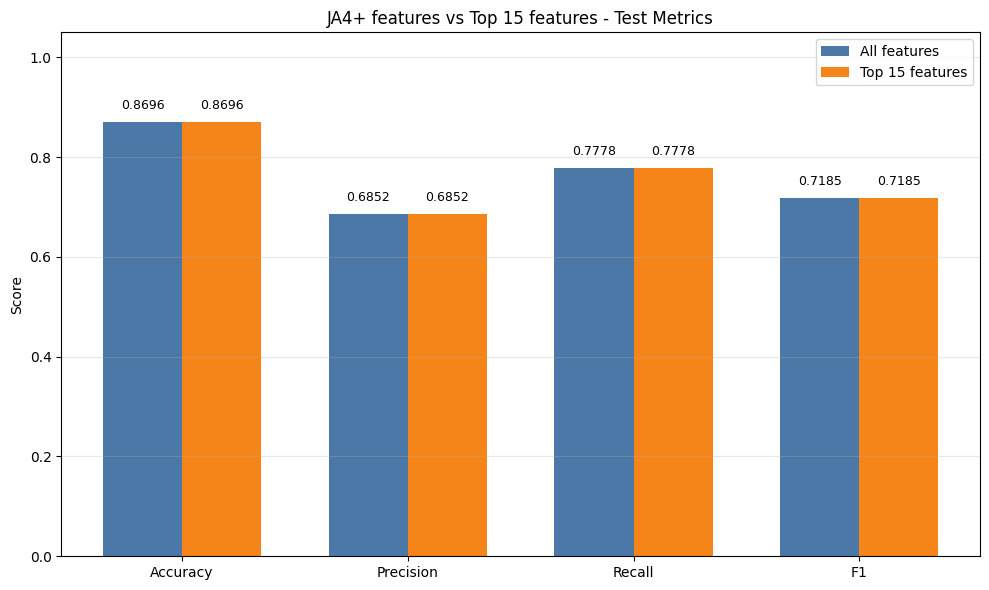

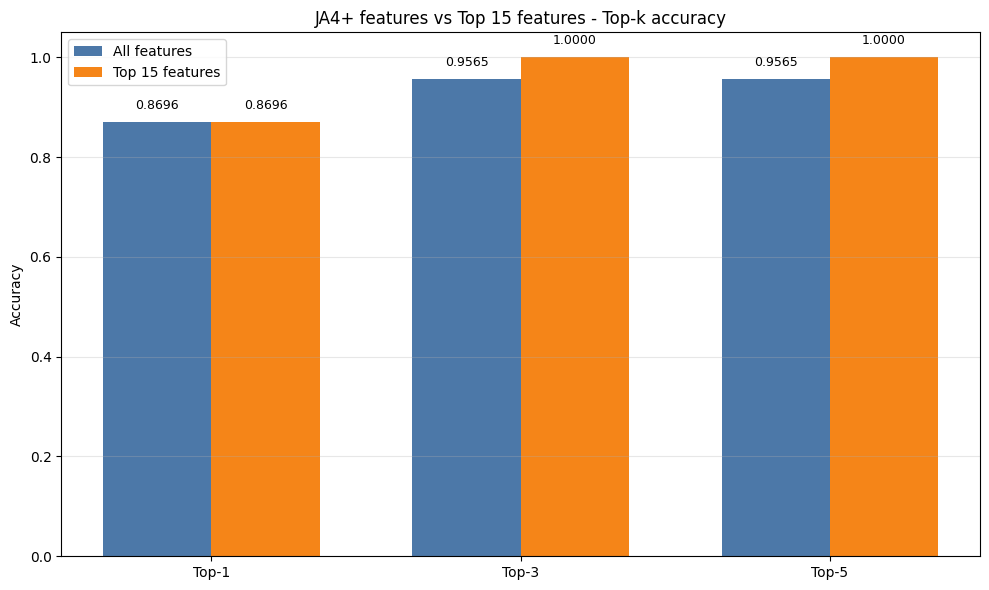

In [13]:
from sklearn.metrics import precision_score, recall_score

# Retraining with the top original features
# Select the best original features from the full model
# Use the exact same Random Forest hyperparameters as the original model.
# Retrain using only the most discriminative original features.
top_feature_count = 15
Top_features = grouped_feature_importance_df['grouped_feature'].head(top_feature_count).tolist()
print('Features used in the top-feature retraining experiment:', Top_features)
print('Using the same hyperparameters as the original model and no additional features.')

df_top = df_model[Top_features + [target_column]].copy()

for column in Top_features:
    if column in categorical_features:
        df_top[column] = df_top[column].fillna('unknown').astype(str).str.strip().str.lower()
    elif column in numeric_features:
        df_top[column] = pd.to_numeric(df_top[column], errors='coerce')
    else:
        df_top[column] = df_top[column].fillna('unknown').astype(str).str.strip().str.lower()

numeric_subset = [c for c in Top_features if c in numeric_features]
if numeric_subset:
    df_top = df_top.dropna(subset=numeric_subset).reset_index(drop=True)

top_device_counts = df_top[target_column].value_counts()
valid_devices_top = top_device_counts[top_device_counts >= min_samples_per_device].index
if len(valid_devices_top) != len(top_device_counts):
    print(f'Categories excluded after top-feature filtering: {len(top_device_counts) - len(valid_devices_top)}')
df_top = df_top[df_top[target_column].isin(valid_devices_top)].reset_index(drop=True)

print(f'Categories kept after using the top {top_feature_count} features: {len(valid_devices_top)}')
print(f'Total samples after top-feature filtering: {len(df_top)}')

X_top = df_top[Top_features].copy()
y_top = df_top[target_column].copy()

X_train_list, X_val_list, X_test_list = [], [], []
y_train_list, y_val_list, y_test_list = [], [], []

for device in valid_devices_top:
    device_mask = df_top[target_column] == device
    X_device = X_top[device_mask].reset_index(drop=True)
    y_device = y_top[device_mask].reset_index(drop=True)

    X_temp, X_test_device, y_temp, y_test_device = train_test_split(
        X_device, y_device, test_size=0.2, random_state=42, shuffle=True
    )
    train_ratio = 0.70 / 0.80
    X_train_device, X_val_device, y_train_device, y_val_device = train_test_split(
        X_temp, y_temp, train_size=train_ratio, random_state=42, shuffle=True
    )

    X_train_list.append(X_train_device)
    X_val_list.append(X_val_device)
    X_test_list.append(X_test_device)
    y_train_list.append(y_train_device)
    y_val_list.append(y_val_device)
    y_test_list.append(y_test_device)

X_train_top = pd.concat(X_train_list, ignore_index=True)
X_val_top = pd.concat(X_val_list, ignore_index=True)
X_test_top = pd.concat(X_test_list, ignore_index=True)
y_train_top = pd.concat(y_train_list, ignore_index=True)
y_val_top = pd.concat(y_val_list, ignore_index=True)
y_test_top = pd.concat(y_test_list, ignore_index=True)

categorical_top = [c for c in Top_features if c in categorical_features]
X_train_top = pd.get_dummies(X_train_top, columns=categorical_top, dtype=np.int8, dummy_na=False, drop_first=False, prefix_sep='=')
X_val_top = pd.get_dummies(X_val_top, columns=categorical_top, dtype=np.int8, dummy_na=False, drop_first=False, prefix_sep='=')
X_test_top = pd.get_dummies(X_test_top, columns=categorical_top, dtype=np.int8, dummy_na=False, drop_first=False, prefix_sep='=')

union_columns_top = set(X_train_top.columns) | set(X_val_top.columns) | set(X_test_top.columns)
for col in union_columns_top:
    if col not in X_train_top.columns:
        X_train_top[col] = 0
    if col not in X_val_top.columns:
        X_val_top[col] = 0
    if col not in X_test_top.columns:
        X_test_top[col] = 0

X_train_top = X_train_top[sorted(union_columns_top)]
X_val_top = X_val_top[sorted(union_columns_top)]
X_test_top = X_test_top[sorted(union_columns_top)]

label_encoder_top = LabelEncoder()
y_train_top = label_encoder_top.fit_transform(y_train_top)
y_val_top = label_encoder_top.transform(y_val_top)
y_test_top = label_encoder_top.transform(y_test_top)

rf_top = RandomForestClassifier(**{**grid_search.best_params_, 'random_state': 42, 'n_jobs': -1})
rf_top.fit(X_train_top, y_train_top)

test_predictions_top = rf_top.predict(X_test_top)
test_accuracy_top = accuracy_score(y_test_top, test_predictions_top)
test_f1_top = f1_score(y_test_top, test_predictions_top, average='macro', zero_division=0)
macro_precision_top = precision_score(y_test_top, test_predictions_top, average='macro', zero_division=0)
macro_recall_top = recall_score(y_test_top, test_predictions_top, average='macro', zero_division=0)

if len(label_encoder_top.classes_) <= 3:
    test_top_3_accuracy_top = 1.0
else:
    test_top_3_accuracy_top = top_k_accuracy_score(
        y_test_top, rf_top.predict_proba(X_test_top), k=3, labels=np.arange(len(label_encoder_top.classes_))
    )

if len(label_encoder_top.classes_) <= 5:
    test_top_5_accuracy_top = 1.0
else:
    test_top_5_accuracy_top = top_k_accuracy_score(
        y_test_top, rf_top.predict_proba(X_test_top), k=5, labels=np.arange(len(label_encoder_top.classes_))
    )

print(f'\\n===== Top {top_feature_count} Feature Results =====')
print(f'Test Accuracy: {test_accuracy_top:.4f}')
print(f'Test Precision (macro): {macro_precision_top:.4f}')
print(f'Test Recall (macro): {macro_recall_top:.4f}')
print(f'Test F1 (macro): {test_f1_top:.4f}')
print(f'Top-3 Accuracy: {test_top_3_accuracy_top:.4f}')
print(f'Top-5 Accuracy: {test_top_5_accuracy_top:.4f}')

all_results = {
    'accuracy': test_accuracy,
    'precision': macro_precision,
    'recall': macro_recall,
    'f1': test_f1_macro,
    'top_3': test_top_3_accuracy,
    'top_5': test_top_5_accuracy,
}
top_results = {
    'accuracy': test_accuracy_top,
    'precision': macro_precision_top,
    'recall': macro_recall_top,
    'f1': test_f1_top,
    'top_3': test_top_3_accuracy_top,
    'top_5': test_top_5_accuracy_top,
}

print(f'\\n===== Comparison: All Features vs Top {top_feature_count} Features =====')
for metric in ['accuracy', 'precision', 'recall', 'f1']:
    diff = top_results[metric] - all_results[metric]
    sign = '+' if diff >= 0 else '-'
    print(f'{metric.capitalize():>9}: all={all_results[metric]:.4f}, top{top_feature_count}={top_results[metric]:.4f}, diff={sign}{abs(diff):.4f}')
print(f"    Top-3 Accuracy: all={all_results['top_3']:.4f}, top{top_feature_count}={top_results['top_3']:.4f}")
print(f"    Top-5 Accuracy: all={all_results['top_5']:.4f}, top{top_feature_count}={top_results['top_5']:.4f}")

labels = ['Accuracy', 'Precision', 'Recall', 'F1']
all_values = [all_results[m] for m in ['accuracy', 'precision', 'recall', 'f1']]
top_values = [top_results[m] for m in ['accuracy', 'precision', 'recall', 'f1']]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width / 2, all_values, width, label='All features', color='#4C78A8')
plt.bar(x + width / 2, top_values, width, label=f'Top {top_feature_count} features', color='#F58518')
plt.xticks(x, labels)
plt.ylim(0, 1.05)
plt.title(f'JA4+ features vs Top {top_feature_count} features - Test Metrics')
plt.ylabel('Score')
plt.grid(axis='y', alpha=0.3)
for i in range(len(labels)):
    plt.text(x[i] - width / 2, all_values[i] + 0.02, f'{all_values[i]:.4f}', ha='center', va='bottom', fontsize=9)
    plt.text(x[i] + width / 2, top_values[i] + 0.02, f'{top_values[i]:.4f}', ha='center', va='bottom', fontsize=9)
plt.legend()
plt.tight_layout()
plt.show()

labels_topk = ['Top-1', 'Top-3', 'Top-5']
all_values_topk = [all_results['accuracy'], all_results['top_3'], all_results['top_5']]
top_values_topk = [top_results['accuracy'], top_results['top_3'], top_results['top_5']]

x = np.arange(len(labels_topk))
plt.figure(figsize=(10, 6))
plt.bar(x - width / 2, all_values_topk, width, label='All features', color='#4C78A8')
plt.bar(x + width / 2, top_values_topk, width, label=f'Top {top_feature_count} features', color='#F58518')
plt.xticks(x, labels_topk)
plt.ylim(0, 1.05)
plt.title(f'JA4+ features vs Top {top_feature_count} features - Top-k accuracy')
plt.ylabel('Accuracy')
plt.grid(axis='y', alpha=0.3)
for i in range(len(labels_topk)):
    plt.text(x[i] - width / 2, all_values_topk[i] + 0.02, f'{all_values_topk[i]:.4f}', ha='center', va='bottom', fontsize=9)
    plt.text(x[i] + width / 2, top_values_topk[i] + 0.02, f'{top_values_topk[i]:.4f}', ha='center', va='bottom', fontsize=9)
plt.legend()
plt.tight_layout()
plt.show()